In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from utils_analysis import *
from collections import Counter
import pickle
import re
import seaborn as sns
from gen_tex import update_latex_macros
import subprocess
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

SKIP TO **Loading Filtered Results** section if data have already been retrieved

# Retrieving Data

In [9]:
def count_total_csv_entries():
    import concurrent.futures
    from functools import partial
    
    def count_rows_in_file(file, prefix):
        if not file.endswith('.csv'):
            return 0
        file_path = prefix + "/" + file
        result = subprocess.run(['wc', '-l', file_path], capture_output=True, text=True)
        try:
            # Subtract 1 for header row
            return int(result.stdout.strip().split()[0]) - 1
        except (ValueError, IndexError):
            print(f"Error processing file: {file}")
            return 0
    
    total_rows = 0
    prefix = "/home/infres/rapaport/results/FULL_2024_08"
    class_files = os.listdir(prefix)
    
    process_file = partial(count_rows_in_file, prefix=prefix)
    with concurrent.futures.ThreadPoolExecutor(max_workers=6) as executor:
        future_to_file = {executor.submit(process_file, file): file for file in class_files}
        
        for i, future in enumerate(concurrent.futures.as_completed(future_to_file)):
            file = future_to_file[future]
            try:
                row_count = future.result()
                total_rows += row_count
                print(f'file: {file} {i+1}/{len(class_files)} - {row_count:,} rows')
            except Exception as e:
                print(f'Error processing {file}: {e}')
    
    print(f"Total number of entries across all CSV files: {total_rows:,}")
    update_latex_macros("numbers.tex", "AlteredCommits", f'{total_rows:,}', 'number')
    return total_rows
count_total_csv_entries()

file: swh:1:snp:4abbe315eb9008f3c36fe2439ad5a4419fffa90c.csv 1/28 - 281,620,543 rows
file: swh:1:snp:77fdf23a7b93c3e477085e63a8228514a5141d81.csv 2/28 - 34,350,683 rows
file: checkpoints 3/28 - 0 rows
file: swh:1:snp:7bdd5a506a8c1bf163fd368523c8b24946cd0d08.csv 4/28 - 159,343,744 rows
file: swh:1:snp:90833b1d9246c51d17ad6d8c1cdc60d584444bd5.csv 5/28 - 182,357,327 rows
file: swh:1:snp:72dbef05d425ee828596e74a92fa6270d955359d.csv 6/28 - 180,747,424 rows
file: swh:1:snp:fa2b95d2e6fc91d0777af2a30c32c427fd559c24.csv 7/28 - 243,766,898 rows
file: focus 8/28 - 0 rows
file: swh:1:snp:f55d9473c9a69f86738c3478c858d55eb7edb65b.csv 9/28 - 161,276,043 rows
file: swh:1:snp:5a5f7a892f39485694421edc0f4aea88f98028a3.csv 10/28 - 163,024,881 rows
file: swh:1:snp:f62a0d62af412170e9ffd95e61a7c87b0ac3f292.csv 11/28 - 67,380,399 rows
file: swh:1:snp:183d6e31cf83bba4a9590045efa949d42b2ba0aa.csv 12/28 - 199,990,826 rows
file: swh:1:snp:2cbadedf325fa41a309aee0f6b9b1aa02a1c85e2.csv 13/28 - 100,183,412 rows
file:

12542848352

## Loading visit type

In [2]:
db = {}
with open('visit_type.pkl', 'rb') as f:
    db = pickle.load(f)

Loading time: **6min**

## Loading stars

In [30]:
db_stars = {}
with open('stars_without_dup.pkl', 'rb') as f:
    db_stars = pickle.load(f)

In [30]:
print(f'Amount of repositories in the GitHub repo/star dataset: {len(db_stars):,}')
update_latex_macros("numbers.tex", "OriginsWithStarWithoutHistoryAlteration", f'{len(db_stars):,}', "number")

Amount of repositories in the GitHub repo/star dataset: 278,827,680


True

## Loading results

In [4]:
prefix = "/home/infres/rapaport/results/FULL_2024_08/focus/classes"
class_files = os.listdir(prefix)
df = pd.DataFrame()
for file in class_files:
    df = pd.concat([df, pd.read_csv(prefix + "/" + file, delimiter=";")])
    #df = pd.read_csv(file, delimiter=";")

Loading time: **40s**

## Filtering
We only keep `git` origin and we remove all branches named `HEAD` because it is an alias.

In [11]:
print("size of all results unfiltered: ", len(df))
update_latex_macros("numbers.tex", "RootCauseCommits", f'{len(df):,}', 'number')

size of all results unfiltered:  10264390


True

In [12]:
df = df[(df['branch_name'] != "HEAD")]
print("size of results when removing \'HEAD\' from branch: ", len(df))
update_latex_macros("numbers.tex", "RootCauseCommitsWihtoutHEAD", f'{len(df):,}', 'number')

size of results when removing 'HEAD' from branch:  9844211


True

In [17]:
origins = df['origin'].drop_duplicates().reset_index(drop=True)
print(f'amount of origins with at least 1 root cause commits: {len(origins):,}')
update_latex_macros("numbers.tex", "OriginsRootCauseCommits", f'{len(origins):,}', 'number')

amount of origins with at least 1 root cause commits: 1,237,353


True

In [18]:
df = df[(df['origin'].map(db) == 'git')]
print("size of results when keeping only git: ", len(df))
update_latex_macros("numbers.tex", "GitRootCauseCommits", f'{len(df):,}', 'number')

size of results when keeping only git:  8720085


True

In [19]:
origins_git = df['origin'].drop_duplicates().reset_index(drop=True)
print(f'amount of git origins with at least 1 root cause commits: {len(origins_git):,}')
update_latex_macros("numbers.tex", "GitOriginsRootCauseCommits", f'{len(origins_git):,}', 'number')

amount of git origins with at least 1 root cause commits: 1,218,547


True

In [12]:
db_stars.head()

,index,origin,stars
0,0,https://github.com/Jatin-8898/flappy-bird-react,2
1,1,https://github.com/MayorgaAbogados/MM_20190730_MainWebsite_App,0
2,2,https://github.com/stewartcintra/omnistack9_app,0
3,3,https://github.com/moyamartin/molokai,0
4,4,https://github.com/godsflaw/testchain-medians,0


In [ ]:
df['origin'] = df['origin'].str.lower()

In [21]:
df.head()

,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories
0,https://github.com/SonyaMoisset/SaaSApp_RUBY-ON-RAILS,swh:1:snp:a19832274d0cbfdba0c9986917bd09b018caa07c,refs/pull/78/head,swh:1:rev:f6afdb795b66d0a79d943e77770bb4f6e7e4379c,swh:1:snp:e5374f7e2f9dfd110bda69770057fecb0c2ee2ef,NaN,DIR,",FileModified"
2,https://github.com/SonyaMoisset/SaaSApp_RUBY-ON-RAILS,swh:1:snp:0dff15e79b3136ebf8974cb5a3250b1383ffb946,refs/pull/78/head,swh:1:rev:8b4699448f39b919fc28fcd7990edcae8890341f,swh:1:snp:ee97c5d760577fe489cb1cc134d733ed9dbf22ea,NaN,DIR,",FileModified"
4,https://github.com/mlesniak/mlesniak.github.io,swh:1:snp:aec585f39a63de81a8a5f3d221d7bd43ac5f892f,refs/heads/gh-pages,swh:1:rev:9965821916130e3d5bdde93c68a97bb34ec6654e,swh:1:snp:f553e234b4d1b92a50ef3f7fcbec00777d3495ae,NaN,DIR,",FileRemoved"
5,https://github.com/Pigmice2733/peregrine-frontend,swh:1:snp:d62caf130969027464f4e9e0918ffeae161dd014,refs/pull/1273/head,swh:1:rev:f398bfbd40943a38d7cf89787b3ed5857ab7a51e,swh:1:snp:b39ce059c3189a99cd3032859bda6b1e70165693,NaN,DIR,",FileModified"
6,https://github.com/erezrokah/aws-custom-resources,swh:1:snp:581e14d43dde27de11e53a496d02f8b28cde1e5b,refs/heads/renovate/axios-1.x,swh:1:rev:bd5eb3b881d8dee4deb3b516d899ba02d88901cf,swh:1:snp:24a0baa740a6cac9c9846469d8e97b255577d903,NaN,DIR,",FileModified"


In [13]:
star_dict = db_stars.set_index('origin')['stars'].to_dict()

In [24]:
df['stars'] = df['origin'].map(star_dict).fillna("Unknown")

In [25]:
df.head()

,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories,stars
0,https://github.com/SonyaMoisset/SaaSApp_RUBY-ON-RAILS,swh:1:snp:a19832274d0cbfdba0c9986917bd09b018caa07c,refs/pull/78/head,swh:1:rev:f6afdb795b66d0a79d943e77770bb4f6e7e4379c,swh:1:snp:e5374f7e2f9dfd110bda69770057fecb0c2ee2ef,NaN,DIR,",FileModified",3.0
2,https://github.com/SonyaMoisset/SaaSApp_RUBY-ON-RAILS,swh:1:snp:0dff15e79b3136ebf8974cb5a3250b1383ffb946,refs/pull/78/head,swh:1:rev:8b4699448f39b919fc28fcd7990edcae8890341f,swh:1:snp:ee97c5d760577fe489cb1cc134d733ed9dbf22ea,NaN,DIR,",FileModified",3.0
4,https://github.com/mlesniak/mlesniak.github.io,swh:1:snp:aec585f39a63de81a8a5f3d221d7bd43ac5f892f,refs/heads/gh-pages,swh:1:rev:9965821916130e3d5bdde93c68a97bb34ec6654e,swh:1:snp:f553e234b4d1b92a50ef3f7fcbec00777d3495ae,NaN,DIR,",FileRemoved",0.0
5,https://github.com/Pigmice2733/peregrine-frontend,swh:1:snp:d62caf130969027464f4e9e0918ffeae161dd014,refs/pull/1273/head,swh:1:rev:f398bfbd40943a38d7cf89787b3ed5857ab7a51e,swh:1:snp:b39ce059c3189a99cd3032859bda6b1e70165693,NaN,DIR,",FileModified",25.0
6,https://github.com/erezrokah/aws-custom-resources,swh:1:snp:581e14d43dde27de11e53a496d02f8b28cde1e5b,refs/heads/renovate/axios-1.x,swh:1:rev:bd5eb3b881d8dee4deb3b516d899ba02d88901cf,swh:1:snp:24a0baa740a6cac9c9846469d8e97b255577d903,NaN,DIR,",FileModified",0.0


We stack together all branches e.g. `refs/pull/{digits}/head`

In [26]:
tmp_df = df['branch_name'].drop_duplicates().reset_index()
print("Amount of branch name in the dataframe: ", len(tmp_df))
update_latex_macros("numbers.tex", "BranchNameUnique", f'{len(tmp_df):,}', "number")

Amount of branch name in the dataframe:  1233793


True

In [4]:
def normalize_branch_name(branch_name):
    pull_pattern = r'refs/pull/\d+/head'
    if re.match(pull_pattern, branch_name):
        return re.sub(r'(?<=refs/pull/)\d+(?=/head)', '{x}', branch_name)
    
    renovate_pattern = r'refs/heads/renovate/.*'
    if re.match(renovate_pattern, branch_name):
        return re.sub(r'refs/heads/renovate/.*', 'refs/heads/renovate/{project}', branch_name)
    
    main_pattern = r'refs/heads/(main|master)'
    if re.match(main_pattern, branch_name):
        return 'refs/heads/{master,main}'
    
    dev_pattern = r'refs/heads/(dev|devel|develop|development)'
    if re.match(dev_pattern, branch_name):
        return 'refs/heads/{dev(el(op(ment)))}'
    
    return branch_name
df['normalized_branch'] = df['branch_name'].apply(normalize_branch_name)

Filtering time: **13s**

In [28]:
tmp_df = df['normalized_branch'].drop_duplicates().reset_index()
print("Amount of branch name in the dataframe after normalizing: ", len(tmp_df))
update_latex_macros("numbers.tex", "BranchNameNormalizedUnique", f'{len(tmp_df):,}', "number")

Amount of branch name in the dataframe after normalizing:  1115052


True

In [ ]:
df["sub_categories"] = df["sub_categories"].fillna(",Other")
df["sub_categories"] = df["sub_categories"].str.replace(",", " ").str.strip()

## Saving Results

In [5]:
df.head()

,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories,stars,normalized_branch
0,https://github.com/SonyaMoisset/SaaSApp_RUBY-ON-RAILS,swh:1:snp:a19832274d0cbfdba0c9986917bd09b018caa07c,refs/pull/78/head,swh:1:rev:f6afdb795b66d0a79d943e77770bb4f6e7e4379c,swh:1:snp:e5374f7e2f9dfd110bda69770057fecb0c2ee2ef,NaN,DIR,FileModified,3.0,refs/pull/{x}/head
2,https://github.com/SonyaMoisset/SaaSApp_RUBY-ON-RAILS,swh:1:snp:0dff15e79b3136ebf8974cb5a3250b1383ffb946,refs/pull/78/head,swh:1:rev:8b4699448f39b919fc28fcd7990edcae8890341f,swh:1:snp:ee97c5d760577fe489cb1cc134d733ed9dbf22ea,NaN,DIR,FileModified,3.0,refs/pull/{x}/head
4,https://github.com/mlesniak/mlesniak.github.io,swh:1:snp:aec585f39a63de81a8a5f3d221d7bd43ac5f892f,refs/heads/gh-pages,swh:1:rev:9965821916130e3d5bdde93c68a97bb34ec6654e,swh:1:snp:f553e234b4d1b92a50ef3f7fcbec00777d3495ae,NaN,DIR,FileRemoved,0.0,refs/heads/gh-pages
5,https://github.com/Pigmice2733/peregrine-frontend,swh:1:snp:d62caf130969027464f4e9e0918ffeae161dd014,refs/pull/1273/head,swh:1:rev:f398bfbd40943a38d7cf89787b3ed5857ab7a51e,swh:1:snp:b39ce059c3189a99cd3032859bda6b1e70165693,NaN,DIR,FileModified,25.0,refs/pull/{x}/head
6,https://github.com/erezrokah/aws-custom-resources,swh:1:snp:581e14d43dde27de11e53a496d02f8b28cde1e5b,refs/heads/renovate/axios-1.x,swh:1:rev:bd5eb3b881d8dee4deb3b516d899ba02d88901cf,swh:1:snp:24a0baa740a6cac9c9846469d8e97b255577d903,NaN,DIR,FileModified,0.0,refs/heads/renovate/{project}


In [6]:
with open('res.pkl', 'wb') as f:
    pickle.dump(df, f)

Saving time: **15s**

# Loading Filtered Results
We can skip this phase if we did the previous ones or we can start here is `res.pkl` exists but still run the [Retrieving stats]() section.

In [2]:
df = pd.read_pickle('res.pkl')

Loading time: **1min**

# Analysis

## Retrieving stats

In [3]:
alone, single, couple, triple = Counter(), Counter(), Counter(), Counter()
stats = [elt for elt in list(map(lambda categ: str(categ).split(" "), df["sub_categories"]))]
out_of = add_relations_v2(alone, single, couple, triple, stats)

In [4]:
df_unknown_stars = df.loc[df['stars'] == "Unknown"]
origins = df_unknown_stars['origin'].drop_duplicates().reset_index()
print("Amount of git origins with an unknown amount of stars: ", len(origins))
update_latex_macros("numbers.tex", "OriginsUnkownStars", f'{len(origins):,}', "number")
df_known_stars = df.loc[df['stars'] != "Unknown"]
origins_known = df_known_stars['origin'].drop_duplicates().reset_index()
print("Amount of git origins with a known amount of stars: ", len(origins_known))
update_latex_macros("numbers.tex", "OriginsKownStars", f'{len(origins_known):,}', "number")

Amount of git origins with an unknown amount of stars:  283203
Amount of git origins with a known amount of stars:  935344


True

In [5]:
df_01_stars = df.loc[df['stars'].apply(lambda x: x == 0 or x == 1)]
origins = df_01_stars['origin'].drop_duplicates().reset_index()
print("Amount of git origins with 0 or 1 star: ", len(origins))
update_latex_macros("numbers.tex", "OriginsZeroOneStar", f'{len(origins):,}', "number")
update_latex_macros("numbers.tex", "PercentOriginsZeroOneStar", f'{(len(origins)/len(origins_known))*100:.1f}', "percent")

Amount of git origins with 0 or 1 star:  676252


True

In [6]:
def convert(x, min, max):
    try:
        x = int(x)
        return x >= min and x <= max
    except:
        return False
origins = df.loc[df['stars'].apply(lambda x: convert(x, 2, 9))]['origin'].drop_duplicates().reset_index()
print("Amount of git origins with between 2 and 9 stars: ", len(origins))
update_latex_macros("numbers.tex", "OriginsTwoNineStars", f'{len(origins):,}', "number")
update_latex_macros("numbers.tex", "PercentOriginsTwoNineStars", f'{(len(origins)/len(origins_known))*100:.1f}', "percent")

Amount of git origins with between 2 and 9 stars:  115431


True

In [7]:
origins = df.loc[df['stars'].apply(lambda x: convert(x, 10, 99))]['origin'].drop_duplicates().reset_index()
print("Amount of git origins with between 10 and 99 stars: ", len(origins))
update_latex_macros("numbers.tex", "OriginsTenNinetyNineStars", f'{len(origins):,}', "number")
update_latex_macros("numbers.tex", "PercentTenNinetyNineStars", f'{(len(origins)/len(origins_known))*100:.1f}', "percent")

Amount of git origins with between 10 and 99 stars:  82519


True

In [8]:
origins = df.loc[df['stars'].apply(lambda x: convert(x, 100, 999))]['origin'].drop_duplicates().reset_index()
print("Amount of git origins with between 100 and 999 stars: ", len(origins))
update_latex_macros("numbers.tex", "OriginsHundredNineHundredNinetyNineStars", f'{len(origins):,}', "number")
update_latex_macros("numbers.tex", "PercentHundredNineHundredNinetyNineStars", f'{(len(origins)/len(origins_known))*100:.1f}', "percent")

Amount of git origins with between 100 and 999 stars:  43416


True

In [9]:
def thousand(x):
    try:
        x = int(x)
        return x >= 1000
    except:
        return False
df_1000_stars = df.loc[df['stars'].apply(thousand)]
origins = df_1000_stars['origin'].drop_duplicates().reset_index()
print("Amount of git origins with 1000 stars or more: ", len(origins))
update_latex_macros("numbers.tex", "OriginsThousandPlusStars", f'{len(origins):,}', "number")
update_latex_macros("numbers.tex", "PercentThousandPlusStars", f'{(len(origins)/len(origins_known))*100:.1f}', "percent")

Amount of git origins with 1000 stars or more:  17726


True

In [10]:
print(f'amount of results: {len(df):,}')
ori = len(df['origin'].drop_duplicates())
print(f'amount of origins: {ori:,}')

amount of results: 8,720,085
amount of origins: 1,218,547


### Amount of altered commits per main category

In [11]:
size = len(df)
meta_size = len(df.loc[df['main_category'] == 'META'])
print("nb META: ", meta_size)
update_latex_macros("numbers.tex", "METARootCauseCommits", f'{meta_size:,}', "number")
update_latex_macros("numbers.tex", "PercentMETARootCauseCommits", f'{(meta_size/len(df))*100:.1f}', "percent")
dbn_size = len(df.loc[df['sub_categories'] == 'DifferentBranchName'])
update_latex_macros("numbers.tex", "DBNRootCauseCommits", f'{dbn_size:,}', "number")
update_latex_macros("numbers.tex", "PercentDBNRootCauseCommits", f'{(dbn_size/len(df))*100:.1f}', "percent")
dir_size = len(df.loc[df['main_category'] == 'DIR']) - dbn_size
print("nb DIR: ", dir_size)
print('nb DBN: ', dbn_size)
update_latex_macros("numbers.tex", "DIRRootCauseCommits", f'{dir_size:,}', "number")
update_latex_macros("numbers.tex", "PercentDIRRootCauseCommits", f'{(dir_size/len(df))*100:.1f}', "percent")
issues = size - meta_size - dir_size
print("issues: ", issues)

nb META:  1160725
nb DIR:  6693247
nb DBN:  866113
issues:  866113


- META: **1,160,725 commits**
- DIR: **7,559,360 commits**
- Issues: **0 commits**

### Quick pick at Loading Issues

In [12]:
li = df.loc[(df['main_category'] != 'META') & (df['main_category'] != 'DIR')]
li

,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories,stars,normalized_branch


## Test Repository
We check that our test repository is in the collected data in each category.

In [13]:
df.loc[df['origin']=="https://github.com/srapaport/missing_commits"]

,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories,stars,normalized_branch
54080,https://github.com/srapaport/missing_commits,swh:1:snp:9344bd2bc46dfc441ed0f07449dd3f171fc6b5c1,refs/heads/main,swh:1:rev:76df8ca7ffae6244a463a280ab16e9a0e5bb5442,swh:1:snp:30ac2ee7ff60cefc8ec5b71903b669904952f482,swh:1:rev:fd7d413ed54e6fad86e44b11511225c23b0e36a0,META,Other,Unknown,"refs/heads/{master,main}"
92621,https://github.com/srapaport/missing_commits,swh:1:snp:17db83d2223346ad7eaf9fd23f68a4c49f2827d9,refs/heads/main,swh:1:rev:3490b87918d649b65065caf66735a633f13a07d1,swh:1:snp:daa0c59835e446975bc44e2a419dcd1889096636,swh:1:rev:29482f554f4c827dff469ebbf154c07b5d718044,META,Author,Unknown,"refs/heads/{master,main}"
92941,https://github.com/srapaport/missing_commits,swh:1:snp:2041f0c4bbb2e1713a8e090b099456c9daff5a73,refs/heads/main,swh:1:rev:ade2d2d4856351f654516ad65da3ec69ab96b06a,swh:1:snp:3ffe9c416d794cc415220c65867e64f996933d85,swh:1:rev:0135969d20841456afc0f6d7fc6ed4e55a264c6f,META,Message,Unknown,"refs/heads/{master,main}"
99711,https://github.com/srapaport/missing_commits,swh:1:snp:97dd416171f4d0e624c3bc2eb22f98c7de63b8bf,refs/heads/main,swh:1:rev:78273395091d3b35583884bd862b1b7fb736773d,swh:1:snp:16896fa81da0d60645dc137f195b61e2fcacbde5,swh:1:rev:fe400ae5071269356cefeb92b60efaaa547702f1,META,Message,Unknown,"refs/heads/{master,main}"
123464,https://github.com/srapaport/missing_commits,swh:1:snp:7171271eacad37e770a2ba16ef9d60aa9412cbe4,refs/heads/main,swh:1:rev:c4bef5c8a50202430ffe77b82aba5ca9c3be588a,swh:1:snp:be6d8c4152fe4004af5a3b188513b982370d101e,NaN,DIR,FileRemoved,Unknown,"refs/heads/{master,main}"
124900,https://github.com/srapaport/missing_commits,swh:1:snp:fed196653ee63deec9156fbabe91b222605cc8d4,refs/heads/main,swh:1:rev:153de376a93a0f67dae4e05164369da2c692b9dd,swh:1:snp:8fc6e990ec745fa0b90c7ef9906e8984902f6352,swh:1:rev:e83f39a4c83ca316494ea38d43ff3bbbaf4179e8,META,Other,Unknown,"refs/heads/{master,main}"
152677,https://github.com/srapaport/missing_commits,swh:1:snp:3ee5f5fe2019c2da8b0292d9bdd75f548e9990c5,refs/heads/main,swh:1:rev:53be6956226811d8b740b1b70e5be378845e1a60,swh:1:snp:aae2c7b2392e8e2f51e009ae4ec9be2eb45e7f74,swh:1:rev:55bc91d546430631372d6f14c684f9abfb3db990,META,Date,Unknown,"refs/heads/{master,main}"
194001,https://github.com/srapaport/missing_commits,swh:1:snp:98edabacefdf054df2b70bb1efb3411809de88be,refs/heads/main,swh:1:rev:96540d7ee681c4992fec121217558485439d3846,swh:1:snp:6ed853f3b77930031b0737f0f963e33ec5eeb97c,swh:1:rev:96540d7ee681c4992fec121217558485439d3846,DIR,DifferentBranchName,Unknown,"refs/heads/{master,main}"
206158,https://github.com/srapaport/missing_commits,swh:1:snp:9a60d1cd678413beef5ca05a3e294837b7d6bf47,refs/heads/main,swh:1:rev:13a742d20c3b433a581c0cf691adc1efa5953d5b,swh:1:snp:d0a91beedc76bd8166ac32accc1aade35410f48e,swh:1:rev:95c2e38c6625a3c4d2cba11ca30e1483bdff1490,META,CommitterDate,Unknown,"refs/heads/{master,main}"
308568,https://github.com/srapaport/missing_commits,swh:1:snp:2a5ab681a4f818de5bfefec9de9bd2b6c99852cf,refs/heads/main,swh:1:rev:9bb7e2132d42b4ea2299906841ffae2921eccfab,swh:1:snp:e44c273fb9ea32690bd922f189586d0ae691a440,swh:1:rev:61439b82ee0334e06abb274b485972e0417bda2c,META,CommitterDate Message Date,Unknown,"refs/heads/{master,main}"


## Graphic Representation

### Single
Representation of each category

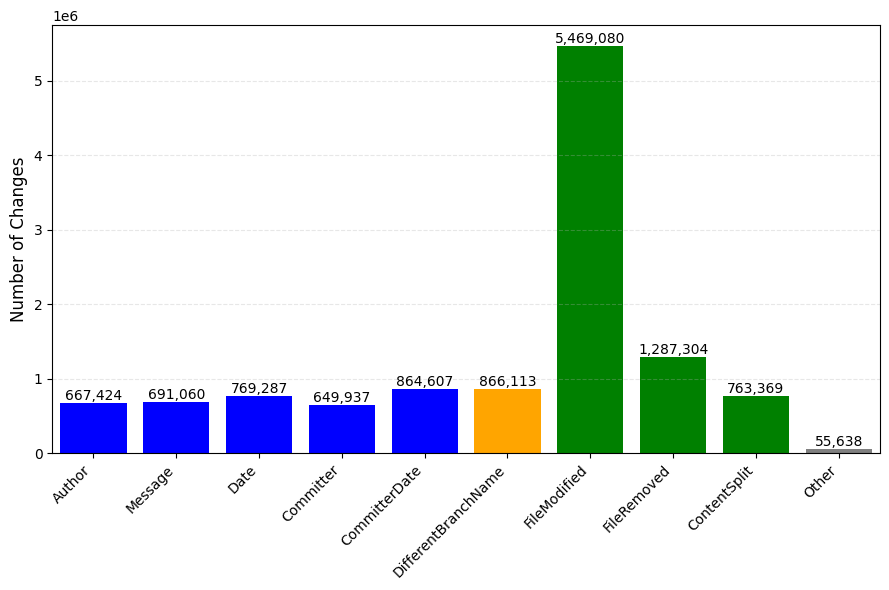

In [14]:
display_single(single)
for categ in single:
    update_latex_macros("numbers.tex", f'Categ{categ}', f'{single[categ]:,}', 'number')
    update_latex_macros("numbers.tex", f'PercentCateg{categ}', f'{(single[categ]/len(df))*100:.1f}', 'percent')

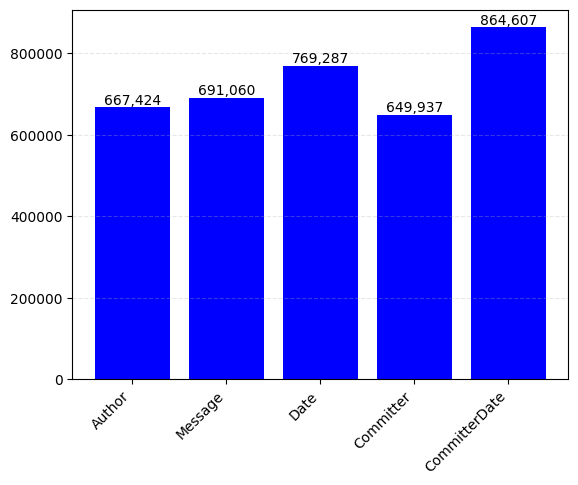

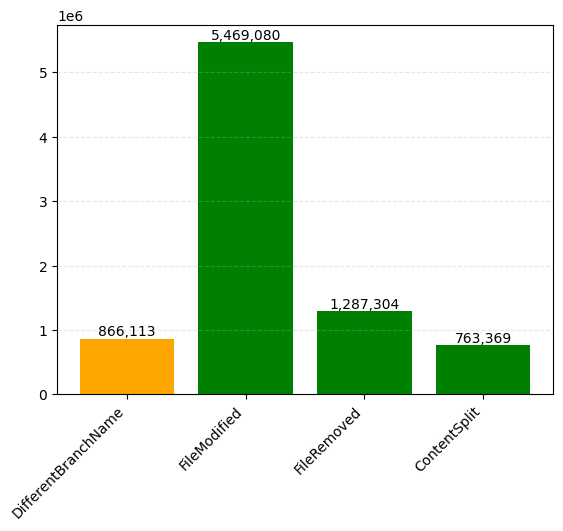

In [15]:
display_single_META(single)
display_single_DIR(single)

- FileModified: **5,469,080**
- FileRemoved: **1,287,304**
- DifferentBranchName: **866,113**
- CommitterDate: **864,607**
- Date: **769,287**
- ContentSplit: **763,369**
- Message: **691,060**
- Author: **667,424**
- Committer: **649,937**
- Other: **55,638**

## Crossing stats
Heatmap of couples and triples

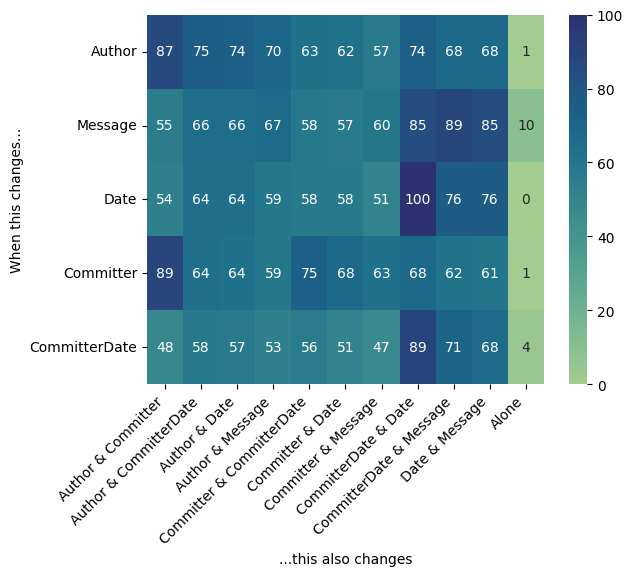

In [16]:
ht = heatmap_triple(triple, couple, single, alone, True)

### Triples under 25%

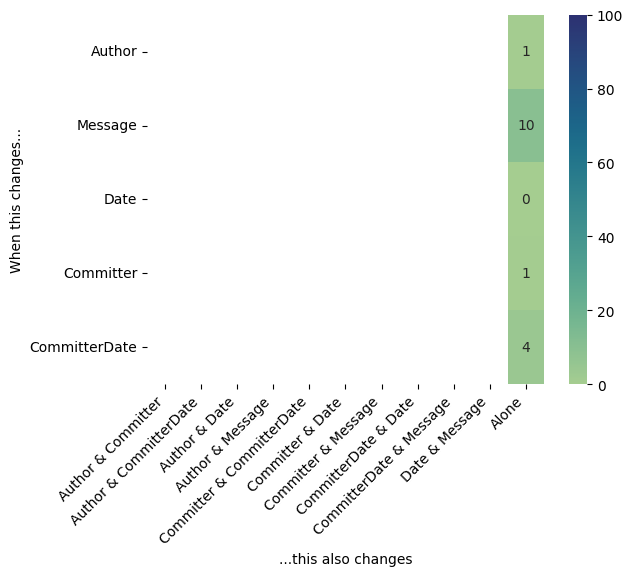

In [17]:
display_triple(ht, filter_percent(ht, 0, 25), with_mask_couple=False)

### Triples above 75%

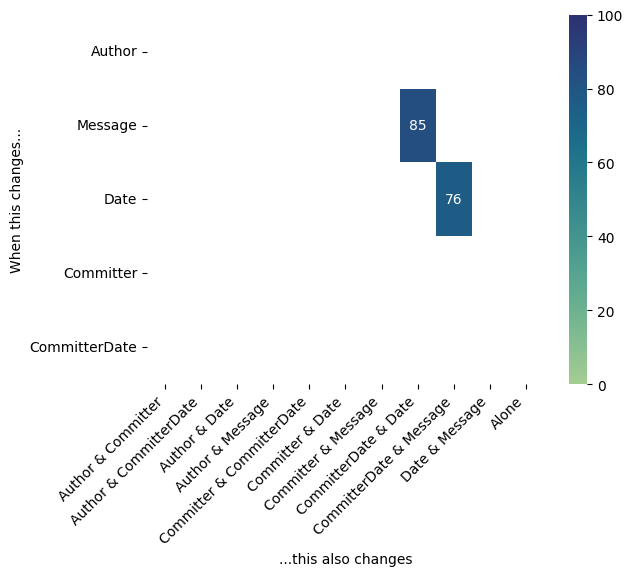

In [18]:
display_triple(ht, filter_percent(ht, 75, 100), with_mask_couple=True)

## Top Branches
Branches that are the most impacted

In [19]:
top_10_branches = df["branch_name"].value_counts().head(20)
print(top_10_branches)

branch_name
refs/heads/master                          916883
refs/heads/gh-pages                        169624
refs/pull/1/head                            64115
refs/heads/main                             62525
refs/heads/renovate/configure               43898
refs/pull/2/head                            29859
refs/heads/develop                          29139
refs/heads/renovate/eslint-8.x              24252
refs/pull/3/head                            23400
refs/pull/4/head                            21359
refs/heads/pre-commit-ci-update-config      20710
refs/pull/5/head                            20139
refs/pull/6/head                            18996
refs/heads/dev                              18851
refs/heads/renovate/major-jest-monorepo     18793
refs/pull/7/head                            17943
refs/heads/renovate/babel-monorepo          17424
refs/pull/8/head                            17315
refs/pull/9/head                            17007
refs/pull/10/head                     

### Normalizing
We gather all pull branches together

In [20]:
top_10_branches_norm = df['normalized_branch'].value_counts().head(20)
print(top_10_branches_norm)

normalized_branch
refs/pull/{x}/head                                   3276081
refs/heads/{master,main}                              993178
refs/heads/renovate/{project}                         833524
refs/heads/gh-pages                                   169624
refs/heads/{dev(el(op(ment)))}                         76812
refs/heads/pre-commit-ci-update-config                 20710
refs/heads/ubuntu/devel                                11927
refs/heads/applied/ubuntu/devel                        11866
refs/heads/wip                                         10317
refs/heads/output                                       9282
refs/heads/dependabot/npm_and_yarn/lodash-4.17.21       8276
refs/heads/next                                         7276
refs/merge-requests/1/merge                             7067
refs/heads/buster-staging                               6475
refs/heads/staging                                      6386
refs/heads/bullseye-staging                             6314
refs/h

In [21]:
branch_df = top_10_branches_norm.reset_index()
branch_df.columns = ['branch', 'count']
total = len(df)
branch_df['percentage'] = (branch_df['count'] / total * 100).round(2)
print(branch_df)

                                               branch    count  percentage
0                                  refs/pull/{x}/head  3276081       37.57
1                            refs/heads/{master,main}   993178       11.39
2                       refs/heads/renovate/{project}   833524        9.56
3                                 refs/heads/gh-pages   169624        1.95
4                      refs/heads/{dev(el(op(ment)))}    76812        0.88
5              refs/heads/pre-commit-ci-update-config    20710        0.24
6                             refs/heads/ubuntu/devel    11927        0.14
7                     refs/heads/applied/ubuntu/devel    11866        0.14
8                                      refs/heads/wip    10317        0.12
9                                   refs/heads/output     9282        0.11
10  refs/heads/dependabot/npm_and_yarn/lodash-4.17.21     8276        0.09
11                                    refs/heads/next     7276        0.08
12                       

In [22]:
name_sub = {
    'refs/pull/{x}/head': 'pull request',
    'refs/heads/{master,main}': 'main',
    'refs/heads/renovate/{project}': 'renovate',
    'refs/heads/{dev(el(op(ment)))}': 'development'
}

In [23]:
branch_stats = branch_df[branch_df['percentage'] > 0.1].copy()
branch_stats['branch'] = branch_stats['branch'].apply(lambda x: name_sub[x] if x in name_sub else x)
branch_stats['branch'] = branch_stats['branch'].str.replace(r'^refs/', '', regex=True)
print(branch_stats)

                              branch    count  percentage
0                       pull request  3276081       37.57
1                               main   993178       11.39
2                           renovate   833524        9.56
3                     heads/gh-pages   169624        1.95
4                        development    76812        0.88
5  heads/pre-commit-ci-update-config    20710        0.24
6                 heads/ubuntu/devel    11927        0.14
7         heads/applied/ubuntu/devel    11866        0.14
8                          heads/wip    10317        0.12
9                       heads/output     9282        0.11


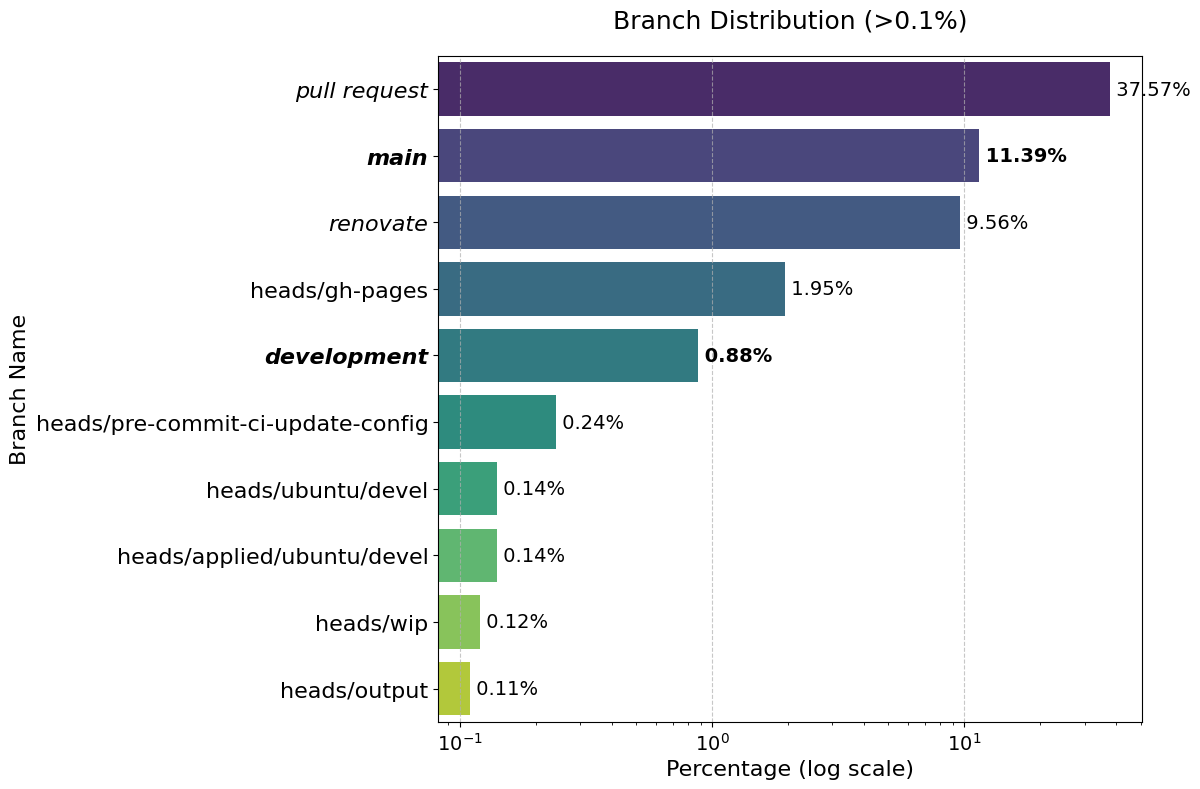

In [24]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=branch_stats, 
           y='branch', 
           x='percentage',
           palette='viridis',
           hue='branch',
           legend=False)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xscale('log')
    
bold_branches = ['main', 'development']
ital_branches = ['main', 'development', 'renovate', 'pull request']
for i, v in enumerate(branch_stats['percentage']):
    branch_name = branch_stats.iloc[i]['branch']
    is_bold = branch_name in bold_branches
    if is_bold:
        plt.text(v, i, f' {v:.2f}%', va='center', fontsize=14, fontweight='bold')
    else:
        plt.text(v, i, f' {v:.2f}%', va='center', fontsize=14)
        
labels = ax.get_yticklabels()
for label in labels:
    branch_name = label.get_text()
    is_bold = branch_name in bold_branches
    is_italic = branch_name in ital_branches
    label.set_fontsize(16)
    if is_bold and is_italic:
        label.set_fontweight('bold')
        label.set_fontstyle('italic')
    elif is_bold:
        label.set_fontweight('bold')
    elif is_italic:
        label.set_fontstyle('italic')

# Set x-axis tick label font size
ax.tick_params(axis='x', labelsize=14)
        
plt.title('Branch Distribution (>0.1%)', pad=20, fontsize=18)
plt.xlabel('Percentage (log scale)', fontsize=16)
plt.ylabel('Branch Name', fontsize=16)
plt.tight_layout()
plt.show()

# Focus on relevant corpus

In [25]:
known = df[df['stars'] != "Unknown"].copy()
known['stars'] = known['stars'].apply(int)
origins = known['origin'].drop_duplicates().reset_index()
update_latex_macros("numbers.tex", "OriginsKnownStars", f'{len(origins):,}', "number")
star_counts = known['stars'].value_counts().sort_index()

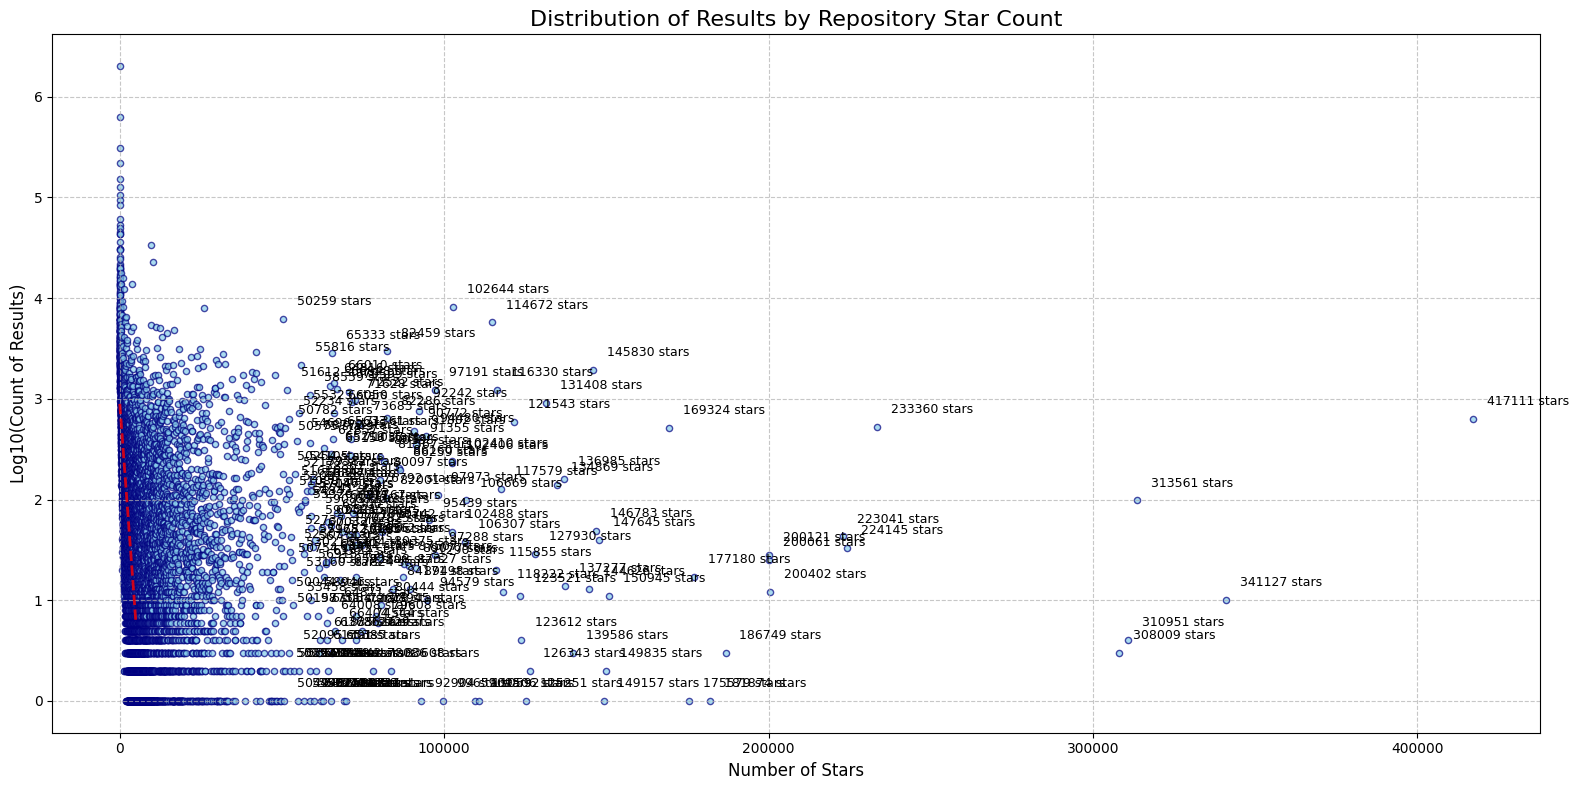

In [26]:
star_df = pd.DataFrame({'stars': star_counts.index, 'count': star_counts.values})

# Apply log transformation for better visualization
star_df['log_count'] = np.log10(star_df['count'])

# Plot setup
plt.figure(figsize=(16, 8))

# Create a scatter plot with points sized by count
plt.scatter(star_df['stars'], star_df['log_count'], 
            alpha=0.7, 
            c='skyblue', 
            edgecolor='navy',
            s=20)

# Add trendline
z = np.polyfit(star_df['stars'][star_df['stars'] < 5000], 
               star_df['log_count'][star_df['stars'] < 5000], 1)
p = np.poly1d(z)
plt.plot(star_df['stars'][star_df['stars'] < 5000], 
         p(star_df['stars'][star_df['stars'] < 5000]), 
         "r--", lw=2, alpha=0.8)

# Add annotations for some high-star repositories
for i in star_df[star_df['stars'] > 50000].index:
    plt.annotate(f"{int(star_df.loc[i, 'stars'])} stars", 
                 (star_df.loc[i, 'stars'], star_df.loc[i, 'log_count']),
                 xytext=(10, 10),
                 textcoords='offset points',
                 fontsize=9)

# Add grid and labels
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Number of Stars', fontsize=12)
plt.ylabel('Log10(Count of Results)', fontsize=12)
plt.title('Distribution of Results by Repository Star Count', fontsize=16)

# Add text showing key statistics
# plt.text(0.02, 0.95, 
#          f"Total repositories: {ori:,}\nRepositories with stars: {ori_with_stars:,} ({ori_with_stars/ori*100:.1f}%)", 
#          transform=plt.gca().transAxes, 
#          bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [28]:
top_stars = known.sort_values(by='stars', ascending=False).head(10)
top_stars

,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories,stars,normalized_branch
216525,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:e7930172e089e3726671aede04621c1d82099707,refs/pull/51204/head,swh:1:rev:0fe82e8e1a7388a52c6a77b4c443692634214eb5,swh:1:snp:305fb083380580391ec752d9c811ca8a8a9bb0cd,NaN,DIR,FileModified,417111,refs/pull/{x}/head
375493,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:305fb083380580391ec752d9c811ca8a8a9bb0cd,refs/pull/51549/head,swh:1:rev:2778a6990a8424485cc1ba2db169d8ccae7734d9,swh:1:snp:c5842ed1d8e09f8e8040d135c6fe07e3bba0e6dd,NaN,DIR,FileModified,417111,refs/pull/{x}/head
167068,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:305fb083380580391ec752d9c811ca8a8a9bb0cd,refs/pull/51443/head,swh:1:rev:9eaeb27decb2d535c848a5c12c5c2e5016595992,swh:1:snp:c5842ed1d8e09f8e8040d135c6fe07e3bba0e6dd,NaN,DIR,FileModified,417111,refs/pull/{x}/head
258494,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:a256330468304885ad1defa18a986dfc29439828,refs/pull/52346/head,swh:1:rev:37d490f14d61c35e5e579c1395425599a4040ac1,swh:1:snp:004d637243c3ca964ea20b710412a3c8cc73664a,NaN,DIR,FileModified,417111,refs/pull/{x}/head
30628,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:5c4f07ccf4ff3d1850da59a421bea212b31ec491,refs/pull/45848/head,swh:1:rev:112d1b4663247fe70c4aace66422b00b9c7ee99b,swh:1:snp:c204e210a6e46d483d0ecc35c5c2fcc44b37d378,NaN,DIR,FileModified,417111,refs/pull/{x}/head
30977,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:a256330468304885ad1defa18a986dfc29439828,refs/heads/i18n-sync-client,swh:1:rev:50041bab61cf5d8ffe6dcfe351ac5e7fc1206f99,swh:1:snp:004d637243c3ca964ea20b710412a3c8cc73664a,swh:1:rev:50041bab61cf5d8ffe6dcfe351ac5e7fc1206f99,DIR,DifferentBranchName,417111,refs/heads/i18n-sync-client
49298,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:7788115347594684cada8290dfe3cefc1e60d21f,refs/pull/43507/head,swh:1:rev:abdf94de504601e04c5a273dae6220ec4d261d8e,swh:1:snp:8abf82e00e0934d6d6e9dc1d4c6879c7f507ba84,NaN,DIR,FileModified FileRemoved,417111,refs/pull/{x}/head
311104,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:3e386cd137359735bfbd0717e9515dc2fe5ed0d4,refs/heads/i18n-sync-curriculum,swh:1:rev:674b3265310f515ce5ff359474c05c39bd2b764f,swh:1:snp:30b2581587a598e8e7f459225c02d1f1d2e8dade,NaN,DIR,FileModified FileRemoved,417111,refs/heads/i18n-sync-curriculum
49826,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:305fb083380580391ec752d9c811ca8a8a9bb0cd,refs/pull/51322/head,swh:1:rev:566182158c7b15e34c9585c8c4d318371ccf1362,swh:1:snp:c5842ed1d8e09f8e8040d135c6fe07e3bba0e6dd,NaN,DIR,FileModified,417111,refs/pull/{x}/head
270622,https://github.com/freeCodeCamp/freeCodeCamp,swh:1:snp:7cfadc8350e18d1d295068a794f22d546ac33a12,refs/pull/49731/head,swh:1:rev:fcde4ee03e9b83e335a6a2bccd490490e9993597,swh:1:snp:73adbf7f7e1bdc6e019edfaed0ac26ab29627064,NaN,DIR,FileModified,417111,refs/pull/{x}/head


In [31]:
star_ranges = [
    (0, 1),          # 0 stars
    (2, 9),          # 1-9 stars
    (10, 99),        # 10-99 stars
    (100, 999),      # 100-999 stars
    (1000, float('inf'))  # 1000+ stars
]
origins_by_range = []
origins_with_alteration_by_range = []
origins_percentages = []
origin_labels = ['0-1', '2-9', '10-99', '100-999', '1000+']
origin_labels_bis = ['ZeroOne', 'TwoNine', 'TenNinetyNine', 'HundredNineHundredNinetyNine', 'ThousandPlus']

known_origins_df = known[['origin', 'stars']].drop_duplicates().reset_index(drop=True)

for low, high in star_ranges:
    origins_with_alteration = len(known_origins_df[(known_origins_df['stars'] >= low) & 
                                               (known_origins_df['stars'] <= high)])
    origins_with_alteration_by_range.append(origins_with_alteration)
    origins_total = len(db_stars[(db_stars['stars'] >= low) & (db_stars['stars'] <= high)])
    origins_by_range.append(origins_total)
    origins_percentages.append((origins_with_alteration/origins_total)*100)

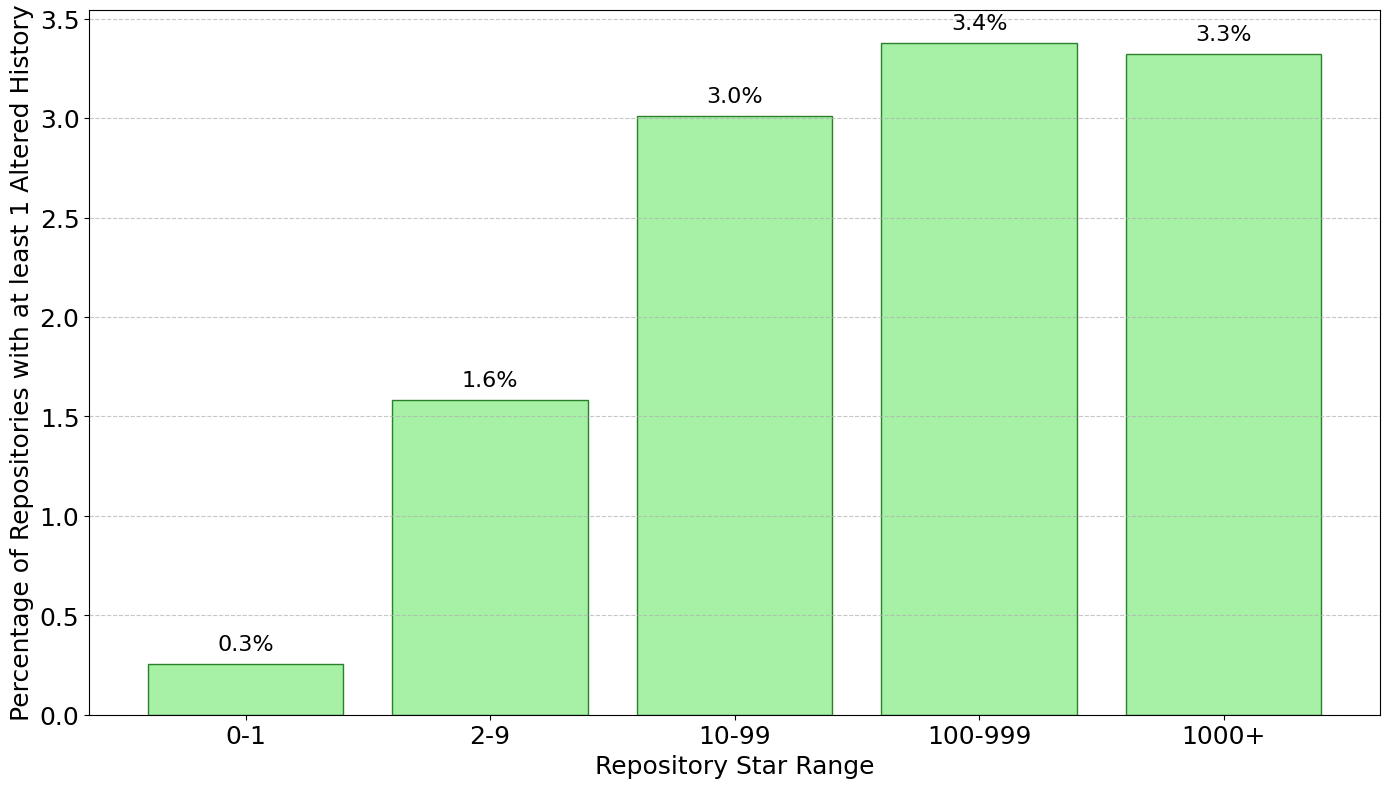

In [35]:
plt.figure(figsize=(14, 8))
bars = plt.bar(origin_labels, origins_percentages, color='lightgreen', edgecolor='darkgreen', alpha=0.8)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height+0.05,
             f'{origins_percentages[i]:.1f}%',
             ha='center', va='bottom', fontsize=16)
    update_latex_macros("numbers.tex", f'PercentOrigins{origin_labels_bis[i]}stars', f'{origins_percentages[i]:.1f}', 'percent')
plt.grid(axis='y', linestyle='--', alpha=0.7)
#plt.title('Proportion of Repositories with Altered Histories per Star Range', fontsize=16, pad=20)
plt.xlabel('Repository Star Range', fontsize=18)
plt.ylabel('Percentage of Repositories with at least 1 Altered History', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

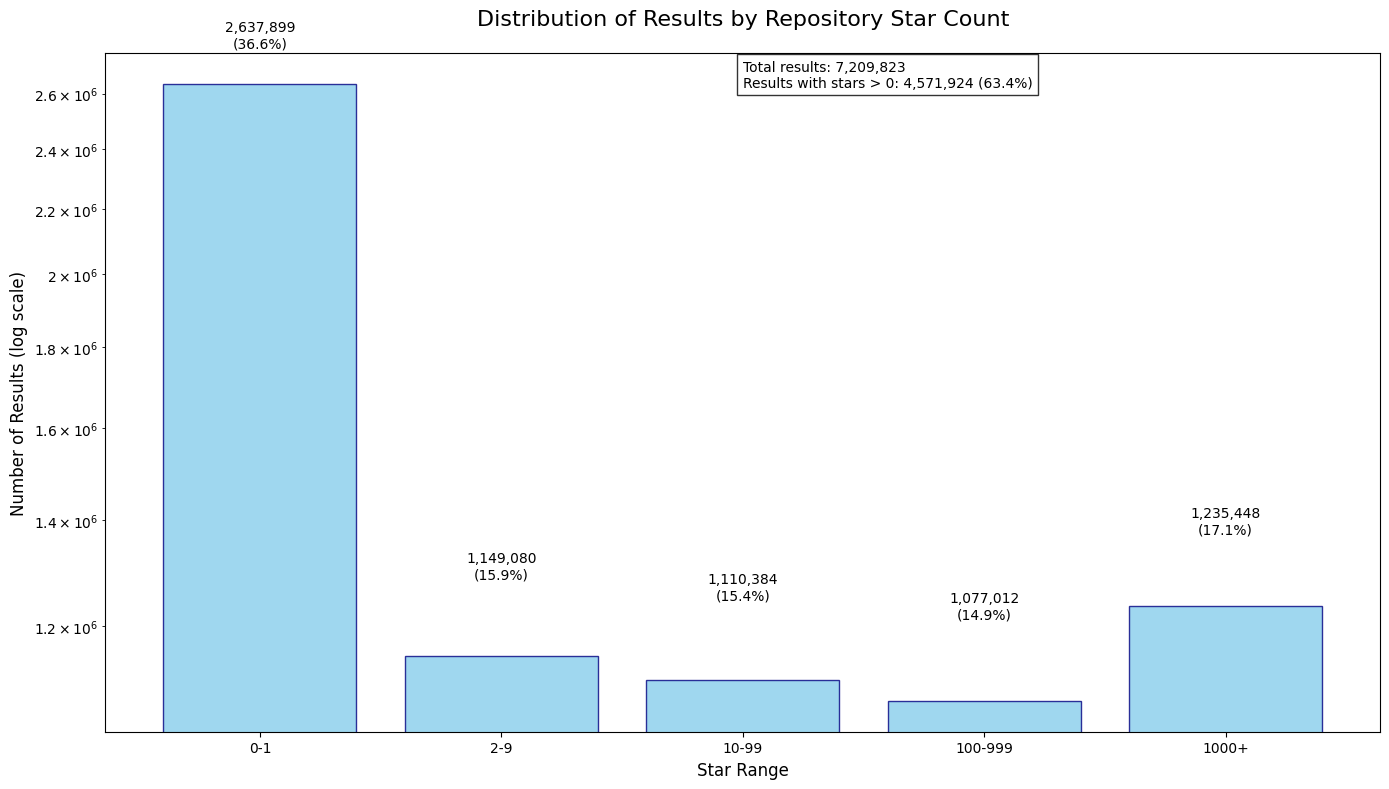

In [36]:
import numpy as np

# Define the star ranges
star_ranges = [
    (0, 1),          # 0 stars
    (2, 9),          # 1-9 stars
    (10, 99),        # 10-99 stars
    (100, 999),      # 100-999 stars
    (1000, float('inf'))  # 1000+ stars
]

# Initialize a list to store counts for each range
counts = []
labels = ['0-1', '2-9', '10-99', '100-999', '1000+']
labels_bis = ['ZeroOne', 'TwoNine', 'TenNinetyNine', 'HundredNineHundredNinetyNine', 'ThousandPlus']

# Count results in each star range
for low, high in star_ranges:
    counts.append(len(known[(known['stars'] >= low) & (known['stars'] <= high)]))

# Calculate percentages
total = sum(counts)
percentages = [(count / total * 100) for count in counts]

# Create the plot
plt.figure(figsize=(14, 8))

# Create a bar chart
bars = plt.bar(labels, counts, color='skyblue', edgecolor='navy', alpha=0.8)

# Add count and percentage labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.05*max(counts),
             f'{counts[i]:,}\n({percentages[i]:.1f}%)',
             ha='center', va='bottom', fontsize=10)
    update_latex_macros("numbers.tex", f'RootCauseCommits{labels_bis[i]}stars', f'{counts[i]:,}', 'number')
    update_latex_macros("numbers.tex", f'PercentRootCauseCommits{labels_bis[i]}stars', f'{percentages[i]:.1f}', 'percent')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set logarithmic scale for y-axis to better visualize the distribution
plt.yscale('log')

# Add title and labels
plt.title('Distribution of Results by Repository Star Count', fontsize=16, pad=20)
plt.xlabel('Star Range', fontsize=12)
plt.ylabel('Number of Results (log scale)', fontsize=12)

# Add a text box with summary statistics
plt.text(0.5, 0.95, 
         f"Total results: {total:,}\n"
         f"Results with stars > 0: {sum(counts[1:]):,} ({sum(counts[1:])/total*100:.1f}%)",
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8),
         fontsize=10)

plt.tight_layout()
plt.show()

In [37]:
df_1000_stars = known.loc[known['stars'] >= 1000]
alone_1000, single_1000, couple_1000, triple_1000 = Counter(), Counter(), Counter(), Counter()
stats_1000 = [elt for elt in list(map(lambda categ: str(categ).split(" "), df_1000_stars["sub_categories"]))]
out_of_1000 = add_relations_v2(alone_1000, single_1000, couple_1000, triple_1000, stats_1000)

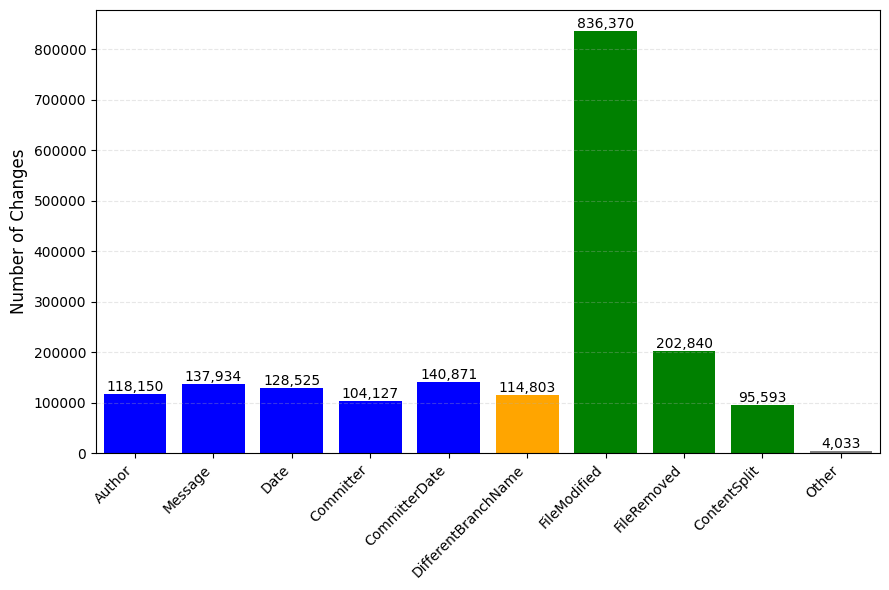

In [38]:
display_single(single_1000)

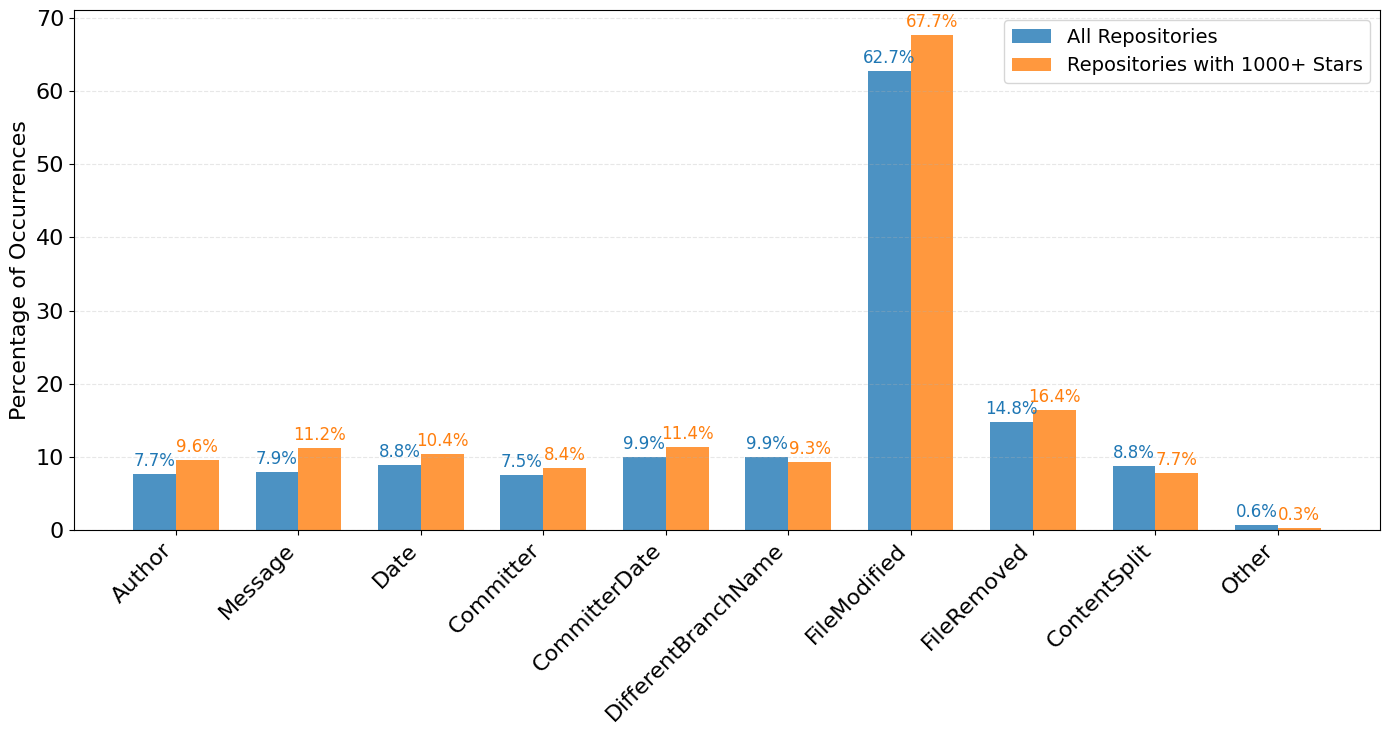

In [55]:
def display_single_dual_scale(stats1, stats2, df, df_1000_stars, title="Comparison of Change Types",
                             label1="All Repositories", label2="Repositories with 1000+ Stars",
                             color1='#1f77b4', color2='#ff7f0e'):
    """
    Display two datasets on the same graph with bars side by side for easier comparison.
    
    Args:
        stats1: First dataset (typically larger numbers)
        stats2: Second dataset (typically smaller numbers)
        title: Title for the plot
        label1: Legend label for first dataset
        label2: Legend label for second dataset
        color1: Color for the first dataset
        color2: Color for the second dataset
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    
    categories = ['Author', 'Message', 'Date', 'Committer', 'CommitterDate', 'DifferentBranchName', 
                  'FileModified', 'FileRemoved', 'ContentSplit', 'Other']
    
    # Extract values for both datasets
    values1 = [(stats1[cat]/len(df))*100 for cat in categories]
    values2 = [(stats2[cat]/len(df_1000_stars))*100 for cat in categories]
    
    # Set width and positions for bars
    bar_width = 0.35
    x = np.arange(len(categories))
    
    # Plot both datasets side by side
    bars1 = ax.bar(x - bar_width/2, values1, bar_width, label=label1, color=color1, alpha=0.8)
    bars2 = ax.bar(x + bar_width/2, values2, bar_width, label=label2, color=color2, alpha=0.8)
    
    # Add value labels on top of each bar
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),  # 3 points vertical offset
                   textcoords="offset points",
                   ha='center', va='bottom',
                   color=color1, fontsize=12)
    
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),  # 3 points vertical offset
                   textcoords="offset points",
                   ha='center', va='bottom',
                   color=color2, fontsize=12)
    
    # Set common axis properties
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=16)
    ax.set_ylabel('Percentage of Occurrences', fontsize=16)
    ax.tick_params(axis='y', labelsize=16)
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')
    
    # Use log scale for y-axis to better compare values of different magnitudes
    #ax.set_yscale('log')
    
    # Add title
    fig.suptitle(title, fontsize=16, y=0.98)
    
    # Add legend
    ax.legend(loc='upper right', fontsize=14)
    
    # Adjust layout to make room for the rotated x-labels
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    
    plt.show()
display_single_dual_scale(single, single_1000, df, df_1000_stars,
                         title="",
                         label1="All Repositories", 
                         label2="Repositories with 1000+ Stars")

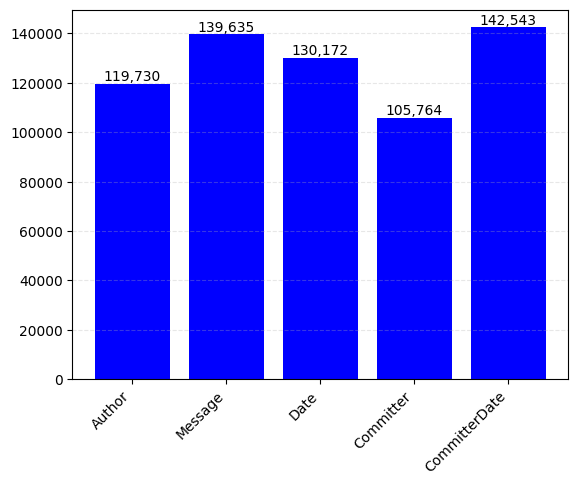

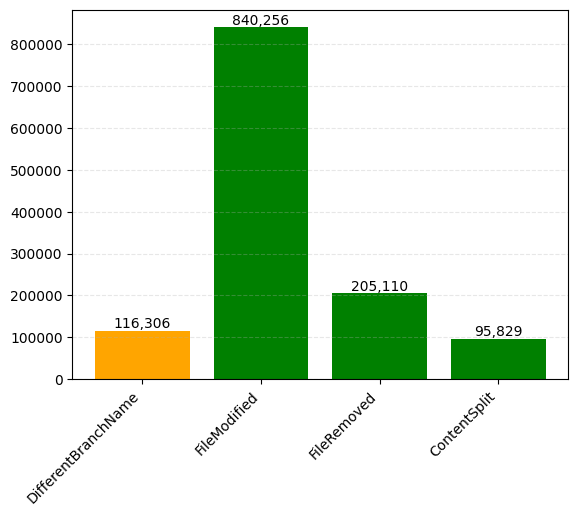

In [ ]:
display_single_META(single_1000)
display_single_DIR(single_1000)

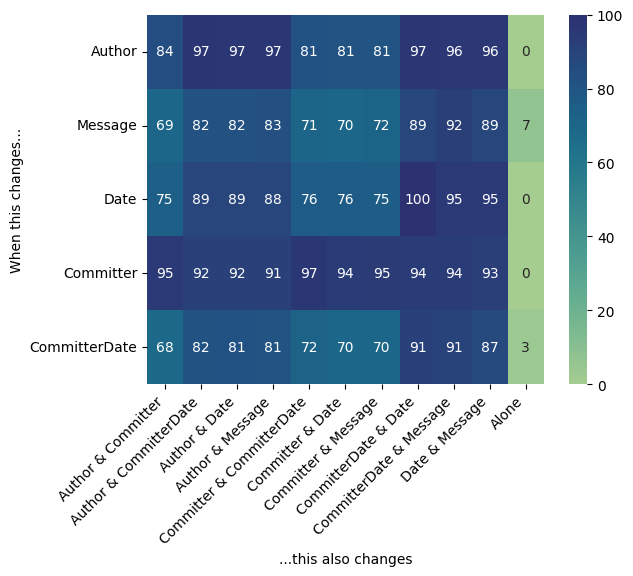

In [ ]:
ht_1000 = heatmap_triple(triple_1000, couple_1000, single_1000, alone_1000, True)

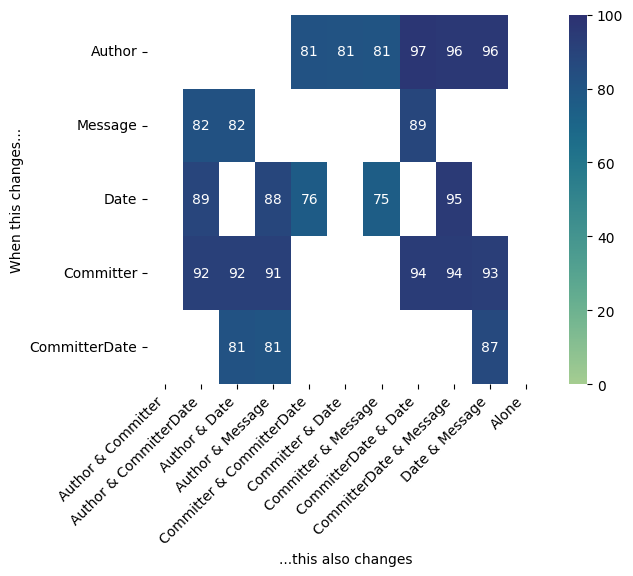

In [ ]:
display_triple(ht_1000, filter_percent(ht_1000, 75, 100), with_mask_couple=True)

In [78]:
df_100_stars = df_known_stars[df_known_stars['stars'] >= 10]
top_10_branches_100_stars = df_100_stars['normalized_branch'].value_counts().head(20)

In [79]:
branch_df_100 = top_10_branches_100_stars.reset_index()
branch_df_100.columns = ['branch', 'count']
total = len(df_100_stars)
branch_df_100['percentage'] = (branch_df_100['count'] / total * 100).round(2)
print(branch_df_100)

                                                      branch    count  \
0                                         refs/pull/{x}/head  1935285   
1                              refs/heads/renovate/{project}   314046   
2                                   refs/heads/{master,main}    62879   
3                                        refs/heads/gh-pages    61245   
4                             refs/heads/{dev(el(op(ment)))}    20824   
5                     refs/heads/pre-commit-ci-update-config    11819   
6                                         refs/heads/staging     3096   
7                                            refs/heads/next     2510   
8                                      refs/heads/linux-next     2377   
9                  refs/heads/release-please--branches--main     2242   
10                                        refs/heads/release     2084   
11         refs/heads/dependabot/npm_and_yarn/lodash-4.17.21     1631   
12                                            refs/

In [80]:
branch_stats_100 = branch_df_100[branch_df_100['percentage'] > 0.1].copy()
branch_stats_100['branch'] = branch_stats_100['branch'].apply(lambda x: name_sub[x] if x in name_sub else x)
branch_stats_100['branch'] = branch_stats_100['branch'].str.replace(r'^refs/', '', regex=True)
print(branch_stats_100)

                              branch    count  percentage
0                       pull request  1935285       56.54
1                           renovate   314046        9.18
2                               main    62879        1.84
3                     heads/gh-pages    61245        1.79
4                        development    20824        0.61
5  heads/pre-commit-ci-update-config    11819        0.35


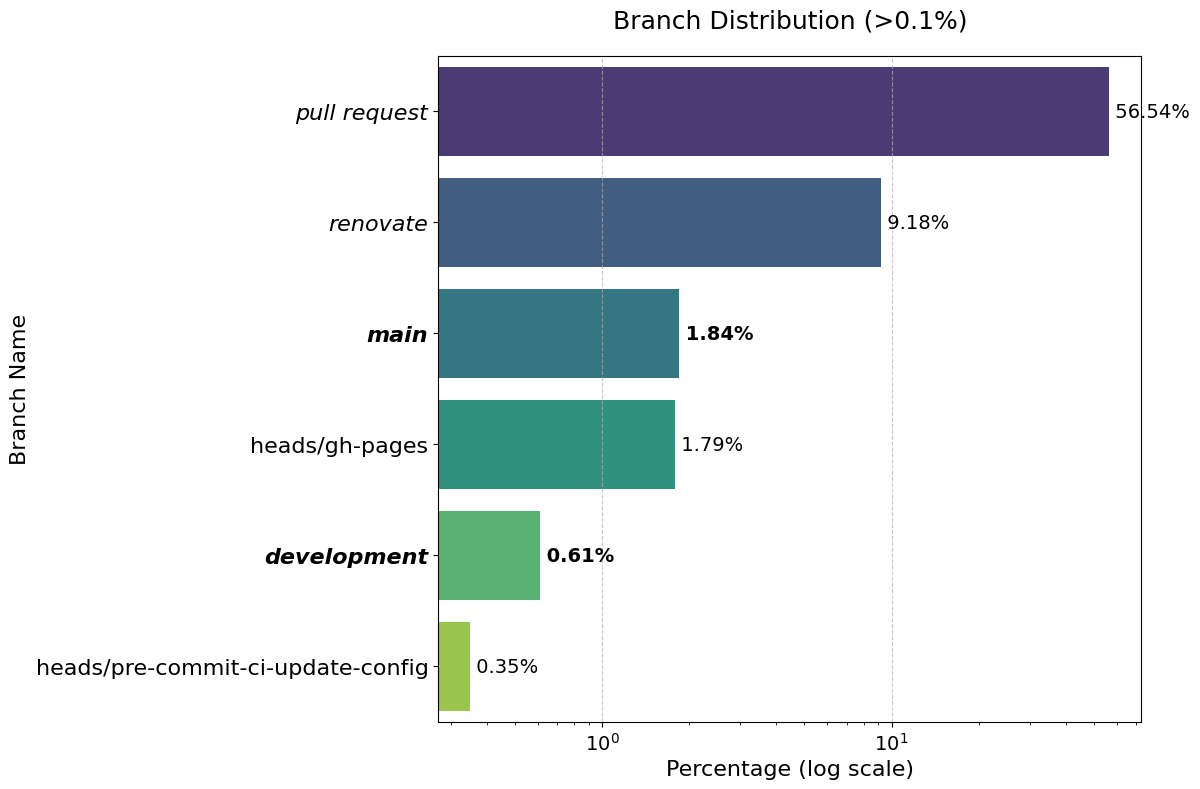

In [81]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=branch_stats_100, 
           y='branch', 
           x='percentage',
           palette='viridis',
           hue='branch',
           legend=False)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xscale('log')
    
bold_branches = ['main', 'development']
ital_branches = ['main', 'development', 'renovate', 'pull request']
for i, v in enumerate(branch_stats_100['percentage']):
    branch_name = branch_stats_100.iloc[i]['branch']
    is_bold = branch_name in bold_branches
    if is_bold:
        plt.text(v, i, f' {v:.2f}%', va='center', fontsize=14, fontweight='bold')
    else:
        plt.text(v, i, f' {v:.2f}%', va='center', fontsize=14)
        
labels = ax.get_yticklabels()
for label in labels:
    branch_name = label.get_text()
    is_bold = branch_name in bold_branches
    is_italic = branch_name in ital_branches
    label.set_fontsize(16)
    if is_bold and is_italic:
        label.set_fontweight('bold')
        label.set_fontstyle('italic')
    elif is_bold:
        label.set_fontweight('bold')
    elif is_italic:
        label.set_fontstyle('italic')

# Set x-axis tick label font size
ax.tick_params(axis='x', labelsize=14)
        
plt.title('Branch Distribution (>0.1%)', pad=20, fontsize=18)
plt.xlabel('Percentage (log scale)', fontsize=16)
plt.ylabel('Branch Name', fontsize=16)
plt.tight_layout()
plt.show()

## Focus on main branches

In [ ]:
df_1000_stars_main = df_1000_stars.loc[df_1000_stars['normalized_branch'] == 'refs/heads/{master/main}']

In [ ]:
ori_1000_stars_main = df_1000_stars_main['origin'].drop_duplicates().reset_index()
print(f'amount of origins with more than 1,000 stars that rewrites the commit\'s history on the main branch: {len(ori_1000_stars_main):,}')

amount of origins with more than 1,000 stars that rewrites the commit's history on the main branch: 2,669


In [ ]:
ori_1000_stars_main_without_dbn = df_1000_stars_main.loc[df_1000_stars_main['sub_categories'] != 'DifferentBranchName']['origin'].drop_duplicates().reset_index()
print(f'amount of origins with more than 1,000 stars that rewrites the commit\'s history on the main branch (other than \'DifferentBranchName\'): {len(ori_1000_stars_main_without_dbn):,}')

amount of origins with more than 1,000 stars that rewrites the commit's history on the main branch (other than 'DifferentBranchName'): 1,461


In [ ]:
alone_1000_main, single_1000_main, couple_1000_main, triple_1000_main = Counter(), Counter(), Counter(), Counter()
stats_1000_main = [elt for elt in list(map(lambda categ: str(categ).split(" "), df_1000_stars_main["sub_categories"]))]
out_of_1000 = add_relations_v2(alone_1000_main, single_1000_main, couple_1000_main, triple_1000_main, stats_1000_main)

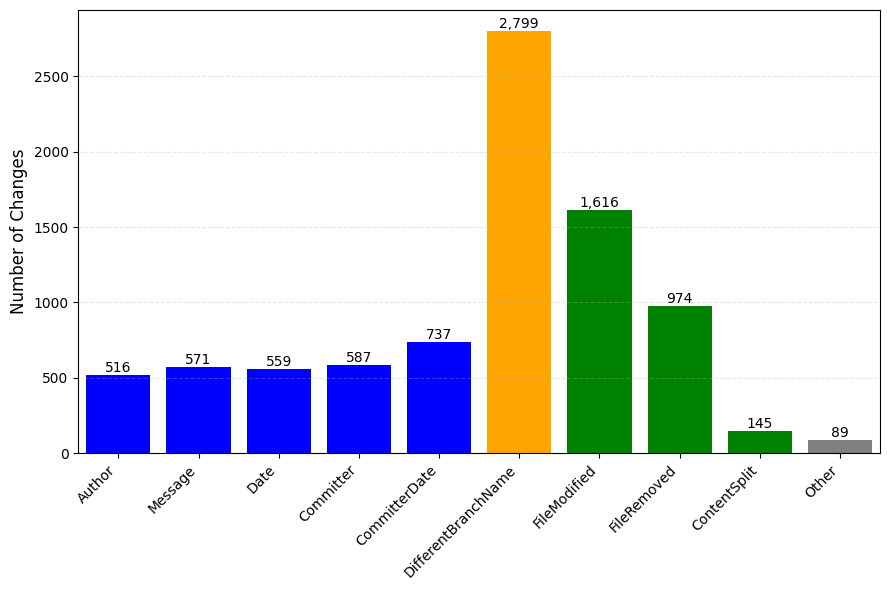

In [ ]:
display_single(single_1000_main)

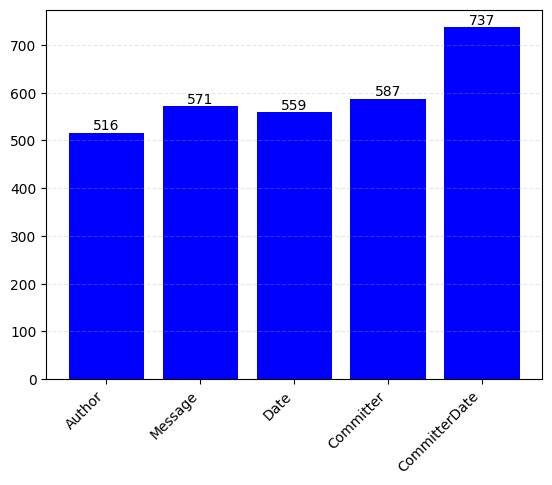

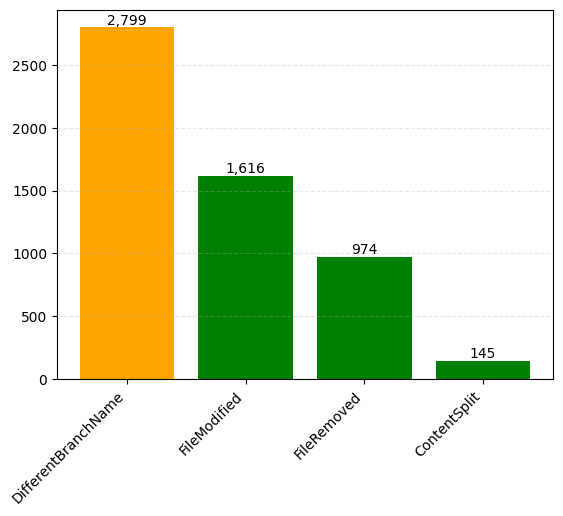

In [ ]:
display_single_META(single_1000_main)
display_single_DIR(single_1000_main)

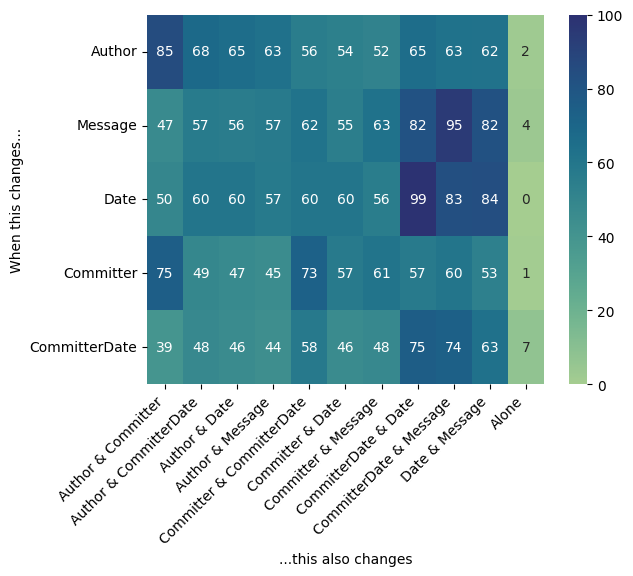

In [ ]:
ht_1000_main = heatmap_triple(triple_1000_main, couple_1000_main, single_1000_main, alone_1000_main, True)

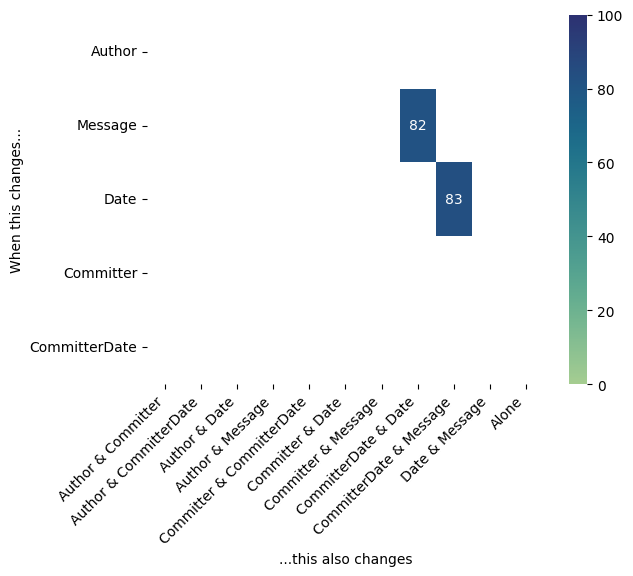

In [ ]:
display_triple(ht_1000_main, filter_percent(ht_1000_main, 75, 100), with_mask_couple=True)